In [100]:
import numpy as np
import pandas as pd


In [101]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

In [102]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [103]:
credits.head(1)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [104]:
movies = movies.merge(credits,on='title')

In [105]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In [106]:
#genres
#id
#keywords
#title
#overview
#cast
#crew
movies = movies[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']]


In [107]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4809 non-null   int64 
 1   title     4809 non-null   object
 2   overview  4806 non-null   object
 3   genres    4809 non-null   object
 4   keywords  4809 non-null   object
 5   cast      4809 non-null   object
 6   crew      4809 non-null   object
dtypes: int64(1), object(6)
memory usage: 263.1+ KB


In [108]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [109]:
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

movies.dropna(inplace=true)

In [110]:
movies.duplicated().sum()

np.int64(0)

In [111]:
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [112]:
# '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"},]'

In [113]:
import ast

In [114]:
def convert(obj):
    L = []
    counter = 0
    
    for i in ast.literal_eval(obj):
        if counter == 3:
            break
        
        L.append(i['name'])
        counter += 1
    
    return L

In [115]:
movies['genres'].apply(convert)

0               [Action, Adventure, Fantasy]
1               [Adventure, Fantasy, Action]
2                 [Action, Adventure, Crime]
3                     [Action, Crime, Drama]
4       [Action, Adventure, Science Fiction]
                        ...                 
4804               [Action, Crime, Thriller]
4805                       [Comedy, Romance]
4806                [Comedy, Drama, Romance]
4807                                      []
4808                           [Documentary]
Name: genres, Length: 4809, dtype: object

In [116]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [117]:
movies['keywords'].head()

0    [{"id": 1463, "name": "culture clash"}, {"id":...
1    [{"id": 270, "name": "ocean"}, {"id": 726, "na...
2    [{"id": 470, "name": "spy"}, {"id": 818, "name...
3    [{"id": 849, "name": "dc comics"}, {"id": 853,...
4    [{"id": 818, "name": "based on novel"}, {"id":...
Name: keywords, dtype: object

In [118]:
def convert3(obj):
    L = []
    counter = 0
    for i in ast.literal_eval(obj):
        if counter != 3:
            L.append(i['name'])
            counter += 1
        else:
            break
    return L

In [119]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [120]:
movies['crew'][0]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [121]:
def fetch_director(obj):
    L = []
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

In [122]:
movies['crew'].apply(fetch_director)



0           [James Cameron]
1          [Gore Verbinski]
2              [Sam Mendes]
3       [Christopher Nolan]
4          [Andrew Stanton]
               ...         
4804     [Robert Rodriguez]
4805         [Edward Burns]
4806          [Scott Smith]
4807          [Daniel Hsia]
4808     [Brian Herzlinger]
Name: crew, Length: 4809, dtype: object

In [123]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [124]:
import ast

def convert(obj):
    if isinstance(obj, list):
        return obj
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

def convert3(obj):
    if isinstance(obj, list):
        return obj
    L = []
    counter = 0
    for i in ast.literal_eval(obj):
        if counter != 3:
            L.append(i['name'])
            counter += 1
        else:
            break
    return L

def fetch_director(obj):
    if isinstance(obj, list):
        return obj
    L = []
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

In [125]:

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies['cast'] = movies['cast'].apply(convert3)
movies['crew'] = movies['crew'].apply(fetch_director)


movies['genres'] = movies['genres'].apply(lambda x: [i.replace(" ", "") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x: [i.replace(" ", "") for i in x])
movies['cast'] = movies['cast'].apply(lambda x: [i.replace(" ", "") for i in x])
movies['crew'] = movies['crew'].apply(lambda x: [i.replace(" ", "") for i in x])

In [126]:
movies['genres']

0       [Action, Adventure, Fantasy, ScienceFiction]
1                       [Adventure, Fantasy, Action]
2                         [Action, Adventure, Crime]
3                   [Action, Crime, Drama, Thriller]
4                [Action, Adventure, ScienceFiction]
                            ...                     
4804                       [Action, Crime, Thriller]
4805                               [Comedy, Romance]
4806               [Comedy, Drama, Romance, TVMovie]
4807                                              []
4808                                   [Documentary]
Name: genres, Length: 4809, dtype: object

In [127]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron]
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski]
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes]
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan]
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton]


In [128]:

movies['overview'] = movies['overview'].apply(lambda x: x.split() if isinstance(x, str) else x)

movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [129]:
movies.head()

,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski],"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes],"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan],"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton],"[John, Carter, is, a, war-weary,, former, mili..."


In [130]:
new_df = movies[['movie_id', 'title','tags']]

In [131]:
new_df

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
...,...,...,...
4804,9367,El Mariachi,"[El, Mariachi, just, wants, to, play, his, gui..."
4805,72766,Newlyweds,"[A, newlywed, couple's, honeymoon, is, upended..."
4806,231617,"Signed, Sealed, Delivered","[""Signed,, Sealed,, Delivered"", introduces, a,..."
4807,126186,Shanghai Calling,"[When, ambitious, New, York, attorney, Sam, is..."


In [132]:
# 1. Safely list ko space-separated string me convert karo
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join([str(i) for i in x]) if isinstance(x, list) else str(x))

# 2. Complete text ko lowercase karo
new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())

C:\Users\Mahi\AppData\Local\Temp\ipykernel_17332\1230944433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: " ".join([str(i) for i in x]) if isinstance(x, list) else str(x))
C:\Users\Mahi\AppData\Local\Temp\ipykernel_17332\1230944433.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())


In [133]:
new_df.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [134]:
new_df['tags'][0]

'in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron'

In [135]:
new_df['tags'] = new_df['tags'].apply = (lambda x:x.lower())

C:\Users\Mahi\AppData\Local\Temp\ipykernel_17332\1206158779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply = (lambda x:x.lower())


In [136]:
new_df.head()

,movie_id,title,tags
0,19995,Avatar,<function <lambda> at 0x0000023A5AC898A0>
1,285,Pirates of the Caribbean: At World's End,<function <lambda> at 0x0000023A5AC898A0>
2,206647,Spectre,<function <lambda> at 0x0000023A5AC898A0>
3,49026,The Dark Knight Rises,<function <lambda> at 0x0000023A5AC898A0>
4,49529,John Carter,<function <lambda> at 0x0000023A5AC898A0>


In [137]:
# 1. 'new_df' ko original 'movies' dataframe se dobara recreate karo
new_df = movies[['movie_id', 'title', 'tags']].copy()

# 2. Tags list ko single space-separated string me convert karo
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

# 3. Pure text ko lowercase karo
new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())

In [138]:
!pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [139]:
import sys
!{sys.executable} -m pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Mahi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [140]:
import nltk

In [141]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [142]:
def stem(text):
    y = []
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

In [143]:
new_df['tags'] = new_df['tags'].apply(stem)

In [144]:
new_df['tags'][0]

'in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav jamescameron'

In [145]:
new_df['tags'][1]

"captain barbossa, long believ to be dead, ha come back to life and is head to the edg of the earth with will turner and elizabeth swann. but noth is quit as it seems. adventur fantasi action ocean drugabus exoticisland eastindiatradingcompani loveofone'slif traitor shipwreck strongwoman ship allianc calypso afterlif fighter pirat swashbuckl aftercreditssting johnnydepp orlandobloom keiraknightley goreverbinski"

In [146]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Mahi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [147]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')

In [148]:
vectors = cv.fit_transform(new_df['tags']).toarray()

In [149]:
vectors

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4809, 5000))

In [150]:
vectors[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

In [151]:
cv.get_feature_names_out()

array(['000', '007', '10', ..., 'zone', 'zoo', 'zooeydeschanel'],
      shape=(5000,), dtype=object)

In [152]:
['loved','loving','love']
['love','love','love']

['love', 'love', 'love']

In [153]:
ps.stem('dancing')

'danc'

In [154]:
stem('in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron')

'in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav jamescameron'

In [155]:
# 1. Ensure tags are joined into strings
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x) if isinstance(x, list) else x)

# 2. Apply stemming
new_df['tags'] = new_df['tags'].apply(stem)

# 3. Re-fit the vectorizer
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

# 4. Check feature names
cv.get_feature_names_out()

array(['000', '007', '10', ..., 'zone', 'zoo', 'zooeydeschanel'],
      shape=(5000,), dtype=object)

In [156]:
cv.get_feature_names_out()[10:30]

array(['17', '18', '18th', '18thcenturi', '19', '1910', '1920', '1930',
       '1940', '1944', '1950', '1950s', '1960', '1960s', '1970', '1970s',
       '1971', '1974', '1976', '1980'], dtype=object)

In [157]:
from sklearn.metrics.pairwise import cosine_similarity

In [158]:
similarity = cosine_similarity(vectors)

In [159]:
sorted(list(enumerate(similarity[0])),reverse=True,key=lambda x:x[1])[1:6]

[(1214, np.float64(0.28676966733820225)),
 (2405, np.float64(0.26901379342448517)),
 (3729, np.float64(0.2605130246476754)),
 (507, np.float64(0.255608593705383)),
 (539, np.float64(0.25038669783359574))]

In [160]:
def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    for i in movies_list:
        print(new_df.iloc[i[0]].title)

In [161]:
recommend('The Dark Knight')

The Dark Knight Rises
Batman Begins
Batman Returns
Batman Forever
Batman


In [162]:
new_df.iloc[1216].title

'Autumn in New York'

In [163]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


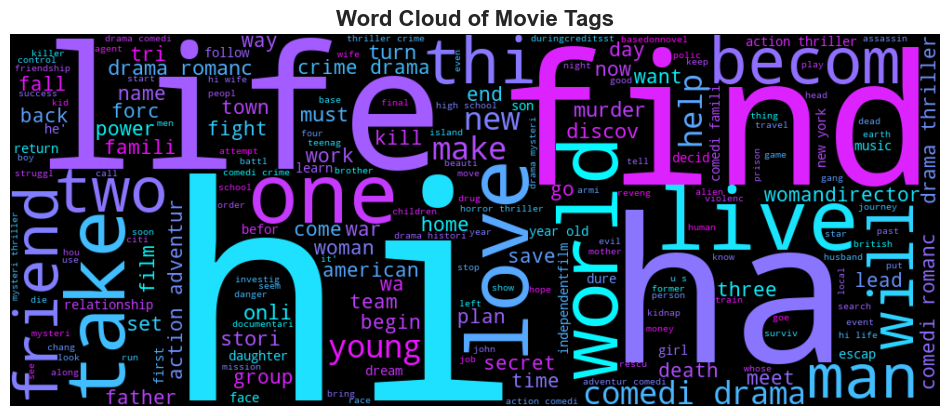

C:\Users\Mahi\AppData\Local\Temp\ipykernel_17332\2218127552.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=scores, y=titles, palette='Blues_r')


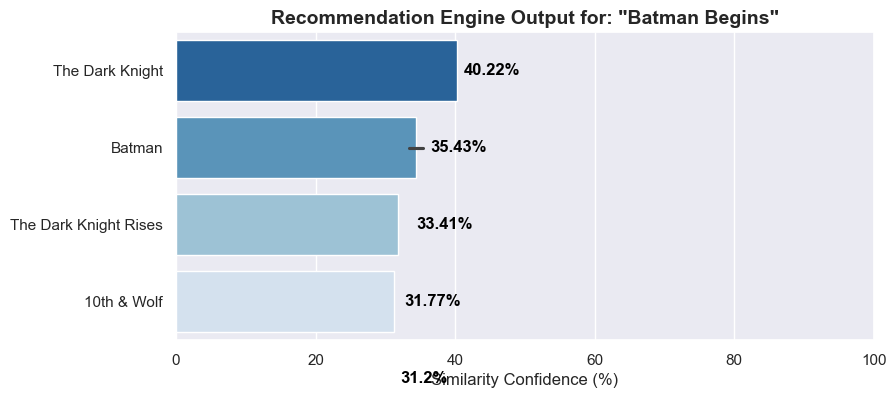

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set visual style
sns.set_theme(style="darkgrid")

# Visual 1: WordCloud of Most Frequent Words in Tags
plt.figure(figsize=(12, 5))
wc = WordCloud(width=1000, height=400, background_color='black', colormap='cool').generate(" ".join(new_df['tags']))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Tags', fontsize=16, fontweight='bold')
plt.show()

# Visual 2: Top 10 Most Similar Movies Visualization
def plot_top_recommendations(movie_name):
    movie_index = new_df[new_df['title'] == movie_name].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    titles = [new_df.iloc[i[0]].title for i in movies_list]
    scores = [round(i[1] * 100, 2) for i in movies_list]
    
    plt.figure(figsize=(9, 4))
    ax = sns.barplot(x=scores, y=titles, palette='Blues_r')
    plt.xlabel('Similarity Confidence (%)', fontsize=12)
    plt.title(f'Recommendation Engine Output for: "{movie_name}"', fontsize=14, fontweight='bold')
    plt.xlim(0, 100)
    
    for i, v in enumerate(scores):
        ax.text(v + 1, i, f'{v}%', color='black', va='center', fontweight='bold')
        
    plt.show()

# Run visual recommendation check
plot_top_recommendations('Batman Begins')

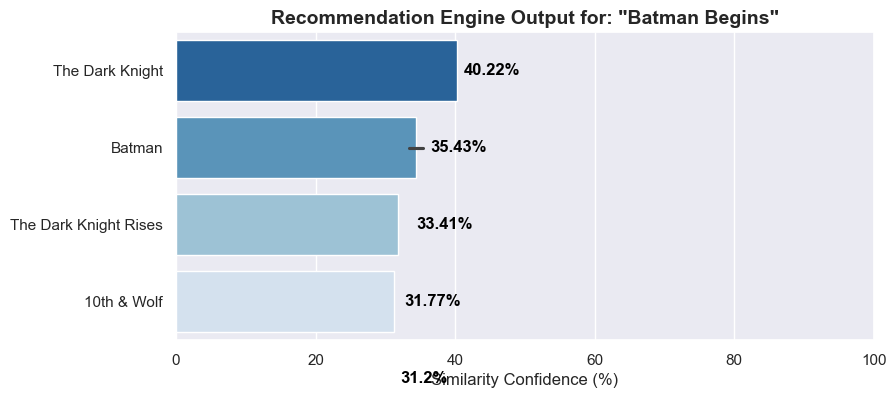

In [165]:
def plot_top_recommendations(movie_name):
    movie_index = new_df[new_df['title'] == movie_name].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    titles = [new_df.iloc[i[0]].title for i in movies_list]
    scores = [round(i[1] * 100, 2) for i in movies_list]
    
    plt.figure(figsize=(9, 4))
    # Modern seaborn syntax (warning fix)
    ax = sns.barplot(x=scores, y=titles, hue=titles, palette='Blues_r', legend=False)
    plt.xlabel('Similarity Confidence (%)', fontsize=12)
    plt.title(f'Recommendation Engine Output for: "{movie_name}"', fontsize=14, fontweight='bold')
    plt.xlim(0, 100)
    
    for i, v in enumerate(scores):
        ax.text(v + 1, i, f'{v}%', color='black', va='center', fontweight='bold')
        
    plt.show()

plot_top_recommendations('Batman Begins')

In [166]:
# ---------------------------------------------------------
# DA PART 1: Data Health & Descriptive Statistics (Fixed)
# ---------------------------------------------------------
print("=== DATASET METRICS ===")
print(f"Total Movies Analyzed: {movies.shape[0]}")
print(f"Total Columns: {movies.shape[1]}")

print("\n=== AVAILABLE COLUMNS ===")
print(list(movies.columns))

print("\n=== MISSING VALUES AUDIT ===")
print(movies.isnull().sum())

=== DATASET METRICS ===
Total Movies Analyzed: 4809
Total Columns: 8

=== AVAILABLE COLUMNS ===
['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew', 'tags']

=== MISSING VALUES AUDIT ===
movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
tags        3
dtype: int64


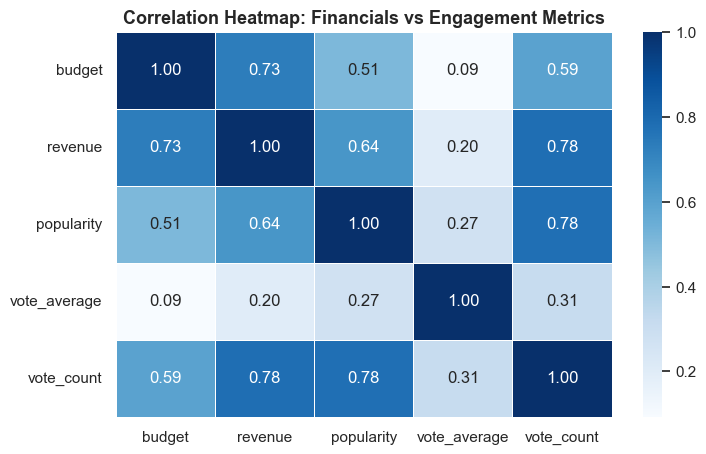

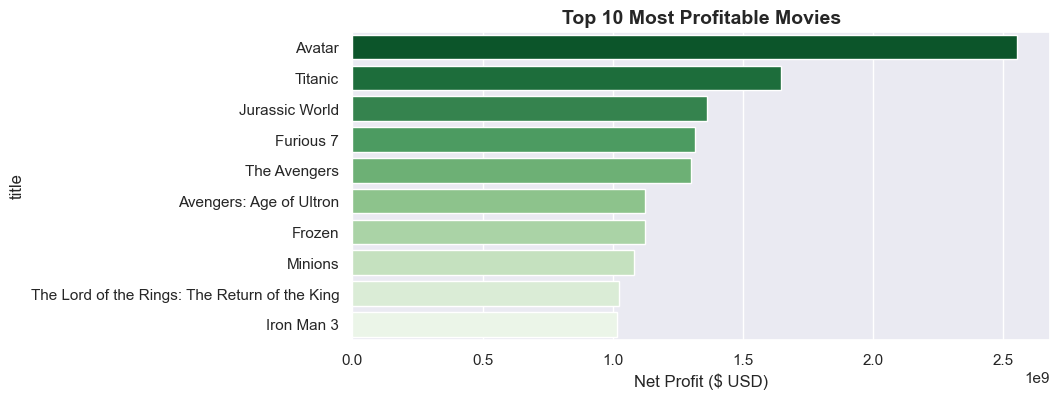

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Raw CSV reload for financial metrics & correlation
raw_movies = pd.read_csv('tmdb_5000_movies.csv')

# 1. Correlation Heatmap
plt.figure(figsize=(8, 5))
num_cols = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']
corr_matrix = raw_movies[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Financials vs Engagement Metrics', fontsize=13, fontweight='bold')
plt.show()

# 2. Top Profitable Movies Chart
financial_df = raw_movies[raw_movies['budget'] > 100000].copy()
financial_df['profit'] = financial_df['revenue'] - financial_df['budget']
top_profit = financial_df.sort_values(by='profit', ascending=False).head(10)

plt.figure(figsize=(9, 4))
ax = sns.barplot(x='profit', y='title', data=top_profit, hue='title', palette='Greens_r', legend=False)
plt.xlabel('Net Profit ($ USD)', fontsize=12)
plt.title('Top 10 Most Profitable Movies', fontsize=14, fontweight='bold')
plt.show()

In [168]:
# ---------------------------------------------------------
# ML UPGRADE: TF-IDF Vectorization & Score Calculation
# ---------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_vectors = tfidf.fit_transform(new_df['tags']).toarray()

tfidf_similarity = cosine_similarity(tfidf_vectors)

# Enhanced Recommend Function
def recommend_tfidf(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = tfidf_similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
    
    print(f"--- Top 5 Advanced Recommendations for '{movie}' ---")
    for i in movies_list:
        print(f"Movie: {new_df.iloc[i[0]].title} | Match Score: {round(i[1]*100, 2)}%")

recommend_tfidf('Batman Begins')

--- Top 5 Advanced Recommendations for 'Batman Begins' ---
Movie: The Dark Knight | Match Score: 36.3%
Movie: The Dark Knight Rises | Match Score: 32.22%
Movie: Batman | Match Score: 29.11%
Movie: Batman v Superman: Dawn of Justice | Match Score: 28.9%
Movie: Batman Returns | Match Score: 27.96%


In [169]:
# ---------------------------------------------------------
# DA EXPORT: Export Dataset for Power BI / Tableau
# ---------------------------------------------------------
export_df = pd.read_csv('tmdb_5000_movies.csv')
export_df['profit'] = export_df['revenue'] - export_df['budget']

export_df.to_csv('movie_data_for_powerbi.csv', index=False)
print("File successfully saved as 'movie_data_for_powerbi.csv'!")

File successfully saved as 'movie_data_for_powerbi.csv'!


In [170]:
# ---------------------------------------------------------
# DEPLOYMENT: Pickle Models for Web Application
# ---------------------------------------------------------
import pickle

# Export dictionary & similarity matrix
pickle.dump(new_df.to_dict(), open('movie_dict.pkl', 'wb'))
pickle.dump(tfidf_similarity, open('similarity.pkl', 'wb'))

print("Model files exported: 'movie_dict.pkl' & 'similarity.pkl'")

Model files exported: 'movie_dict.pkl' & 'similarity.pkl'


In [171]:
import os

# Save directly to Mac Desktop
desktop_path = os.path.expanduser('~/Desktop/movie_data_for_powerbi.csv')
export_df.to_csv(desktop_path, index=False)

print("File successfully saved directly on your Desktop!")

File successfully saved directly on your Desktop!


In [172]:
import pandas as pd
import json

# Load dataset
df = pd.read_csv("tmdb_5000_movies.csv")

# 1. Clean JSON Genres
def parse_genres(x):
    try:
        genres = json.loads(x)
        return ", ".join([g['name'] for g in genres])
    except:
        return ""

df['Clean_Genres'] = df['genres'].apply(parse_genres)

# 2. Calculate ROI (Return on Investment) & Profit
df['profit'] = df['revenue'] - df['budget']
df['ROI'] = ((df['revenue'] - df['budget']) / df['budget'].replace(0, 1)) * 100

# Overwrite CSV for Tableau
df.to_csv("movie_data_for_powerbi.csv", index=False)
print("Dataset Cleaned & Exported Successfully!")

Dataset Cleaned & Exported Successfully!


In [173]:
import os
desktop_path = os.path.expanduser('~/Desktop/movie_clean_data.csv')
df.to_csv(desktop_path, index=False)
print("Saved successfully to Desktop!")

Saved successfully to Desktop!


In [174]:
import pandas as pd

# Assume df is your loaded dataframe
# 1. Top 5 Most Profitable Movies
df['profit'] = df['revenue'] - df['budget']
top_5_profitable = df[['title', 'budget', 'revenue', 'profit']].sort_values(by='profit', ascending=False).head(5)
print("--- Top 5 Most Profitable Movies ---")
print(top_5_profitable)

# 2. Genre-wise Average Budget & Revenue Analysis
genre_analysis = df.groupby('genres').agg(
    avg_budget=('budget', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_profit=('profit', 'mean')
).reset_index().sort_values(by='avg_profit', ascending=False)
print("\n--- Genre-wise Analysis ---")
print(genre_analysis.head())

# 3. High-ROI Blockbusters Filter
df['roi_multiplier'] = df['revenue'] / df['budget'].replace(0, float('nan'))
high_roi = df[df['budget'] > 1000000][['title', 'budget', 'revenue', 'roi_multiplier']].sort_values(by='roi_multiplier', ascending=False).head(10)
print("\n--- Top High-ROI Movies ---")
print(high_roi)

--- Top 5 Most Profitable Movies ---
             title     budget     revenue      profit
0           Avatar  237000000  2787965087  2550965087
25         Titanic  200000000  1845034188  1645034188
28  Jurassic World  150000000  1513528810  1363528810
44       Furious 7  190000000  1506249360  1316249360
16    The Avengers  220000000  1519557910  1299557910

--- Genre-wise Analysis ---
                                                 genres   avg_budget  \
64    [{"id": 10751, "name": "Family"}, {"id": 14, "...  200000000.0   
467   [{"id": 18, "name": "Drama"}, {"id": 28, "name...  185000000.0   
60    [{"id": 10751, "name": "Family"}, {"id": 12, "...  175000000.0   
122   [{"id": 12, "name": "Adventure"}, {"id": 14, "...  150000000.0   
1094  [{"id": 878, "name": "Science Fiction"}, {"id"...   10500000.0   

       avg_revenue   avg_profit  
64    1.025491e+09  825491110.0  
467   1.004558e+09  819558444.0  
60    9.665506e+08  791550600.0  
122   9.382127e+08  788212738.0  
1094  7

In [175]:
import json

# Function to extract clean genre names from JSON string/list
def extract_genres(genre_str):
    try:
        if pd.isna(genre_str):
            return "Unknown"
        # Parse JSON if it's stored as a stringified list of dicts
        genres_list = json.loads(genre_str.replace("'", '"')) if isinstance(genre_str, str) else genre_str
        names = [g['name'] for g in genres_list if isinstance(g, dict) and 'name' in g]
        return ", ".join(names) if names else "Unknown"
    except Exception:
        return "Unknown"

# Apply cleanup to the dataframe
df['clean_genres'] = df['genres'].apply(extract_genres)

# Check the cleaned genres
print(df[['title', 'clean_genres']].head())

                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                  clean_genres  
0  Action, Adventure, Fantasy, Science Fiction  
1                   Adventure, Fantasy, Action  
2                     Action, Adventure, Crime  
3               Action, Crime, Drama, Thriller  
4           Action, Adventure, Science Fiction  


In [176]:
# ============================================================
# BUSINESS PERFORMANCE KPIs
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load movie financial data
movies_raw = pd.read_csv("tmdb_5000_movies.csv")

# Create a separate dataframe for movies with valid financial data
financial_df = movies_raw[
    (movies_raw["budget"] > 0) &
    (movies_raw["revenue"] > 0)
].copy()

# Calculate business metrics
financial_df["profit"] = (
    financial_df["revenue"] - financial_df["budget"]
)

financial_df["roi"] = (
    financial_df["profit"] / financial_df["budget"]
)

# Portfolio KPIs
total_movies = len(financial_df)
total_budget = financial_df["budget"].sum()
total_revenue = financial_df["revenue"].sum()
total_profit = financial_df["profit"].sum()

average_roi = financial_df["roi"].mean()
median_roi = financial_df["roi"].median()

profitable_rate = (
    financial_df["profit"] > 0
).mean()

loss_rate = (
    financial_df["profit"] < 0
).mean()

print("=" * 55)
print("MOVIE BUSINESS PERFORMANCE DASHBOARD")
print("=" * 55)

print(f"Movies analysed       : {total_movies:,}")
print(f"Total budget          : ${total_budget:,.0f}")
print(f"Total revenue         : ${total_revenue:,.0f}")
print(f"Total profit          : ${total_profit:,.0f}")
print(f"Average ROI           : {average_roi:.2f}x")
print(f"Median ROI            : {median_roi:.2f}x")
print(f"Profitability rate    : {profitable_rate:.1%}")
print(f"Loss rate             : {loss_rate:.1%}")

print("=" * 55)

MOVIE BUSINESS PERFORMANCE DASHBOARD
Movies analysed       : 3,229
Total budget          : $131,273,202,176
Total revenue         : $391,493,508,997
Total profit          : $260,220,306,821
Average ROI           : 2953.82x
Median ROI            : 1.30x
Profitability rate    : 75.5%
Loss rate             : 24.4%


In [177]:
# ============================================================
# TOP PROFITABLE MOVIES
# ============================================================

top_profitable_movies = financial_df[
    ["title", "budget", "revenue", "profit", "roi"]
].sort_values(
    by="profit",
    ascending=False
).head(10)

top_profitable_movies

,title,budget,revenue,profit,roi
0,Avatar,237000000,2787965087,2550965087,10.763566
25,Titanic,200000000,1845034188,1645034188,8.225171
28,Jurassic World,150000000,1513528810,1363528810,9.090192
44,Furious 7,190000000,1506249360,1316249360,6.927628
16,The Avengers,220000000,1519557910,1299557910,5.907081
7,Avengers: Age of Ultron,280000000,1405403694,1125403694,4.019299
124,Frozen,150000000,1274219009,1124219009,7.494793
546,Minions,74000000,1156730962,1082730962,14.631499
329,The Lord of the Rings: The Return of the King,94000000,1118888979,1024888979,10.903074
31,Iron Man 3,200000000,1215439994,1015439994,5.077200


In [178]:
# ============================================================
# TOP ROI MOVIES
# ============================================================

top_roi_movies = financial_df[
    ["title", "budget", "revenue", "profit", "roi"]
].sort_values(
    by="roi",
    ascending=False
).head(10)

top_roi_movies

,title,budget,revenue,profit,roi
4238,Modern Times,1,8500000,8499999,8.499999e+06
3137,Nurse 3-D,10,10000000,9999990,9.999990e+05
4577,Paranormal Activity,15000,193355800,193340800,1.288939e+04
4582,Tarnation,218,1162014,1161796,5.329339e+03
4496,The Blair Witch Project,60000,248000000,247940000,4.132333e+03
4724,Eraserhead,10000,7000000,6990000,6.990000e+02
4788,Pink Flamingos,12000,6000000,5988000,4.990000e+02
4742,Super Size Me,65000,28575078,28510078,4.386166e+02
4723,The Gallows,100000,42664410,42564410,4.256441e+02
4514,Open Water,130000,54667954,54537954,4.195227e+02


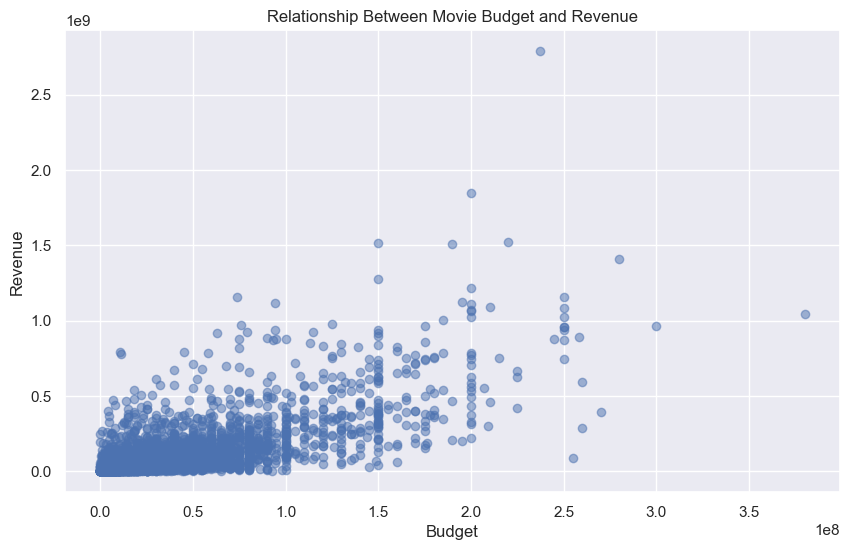

In [179]:
# ============================================================
# BUDGET VS REVENUE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    financial_df["budget"],
    financial_df["revenue"],
    alpha=0.5
)

plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Relationship Between Movie Budget and Revenue")

plt.show()